# Task 1: Dataset Understanding and Literature Review

This notebook consumes the Clean Architecture `FetchRawDataUseCase` and `AnalyzeTargetUseCase` to retrieve the Adult Income dataset and analyze its target class distribution.


In [4]:
import os
import sys
# Add src to path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), 'src')))

from di.container import AppContainer
from IPython.display import Image, display

# Setup Dependency Injection Container
container = AppContainer()
container.config.from_dict({
    "data": {
        "data_dir": os.path.join(os.getcwd(), "data")
    }
})


In [5]:
# 1. Fetch raw data from UCI repository
fetch_usecase = container.fetch_raw_data_usecase()
df = fetch_usecase.execute()
df.head()


2026-07-18 01:05:53,193 | INFO     | [ML_CW] Fetched dataset: 48842 rows, 14 features
2026-07-18 01:05:53,309 | INFO     | [ML_CW] Raw data saved successfully
2026-07-18 01:05:53,310 | INFO     | [ML_CW] FetchRawDataUseCase execution complete


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


2026-07-18 01:05:53,320 | INFO     | [ML_CW] Executing AnalyzeTargetUseCase...
2026-07-18 01:05:53,362 | INFO     | [ML_CW] Loaded raw data: 48842 rows
2026-07-18 01:05:53,364 | INFO     | [ML_CW] Class distribution counts:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
2026-07-18 01:05:53,365 | INFO     | [ML_CW] Class imbalance ratio: 3.18:1
2026-07-18 01:05:53,422 | INFO     | [ML_CW] Saved income distribution plot to /Users/chamikadeshan/Documents/DataScience/MSc/Repos/ML_CW/Q1/outputs/task1/target_distribution.png
2026-07-18 01:05:53,423 | INFO     | [ML_CW] AnalyzeTargetUseCase execution complete.


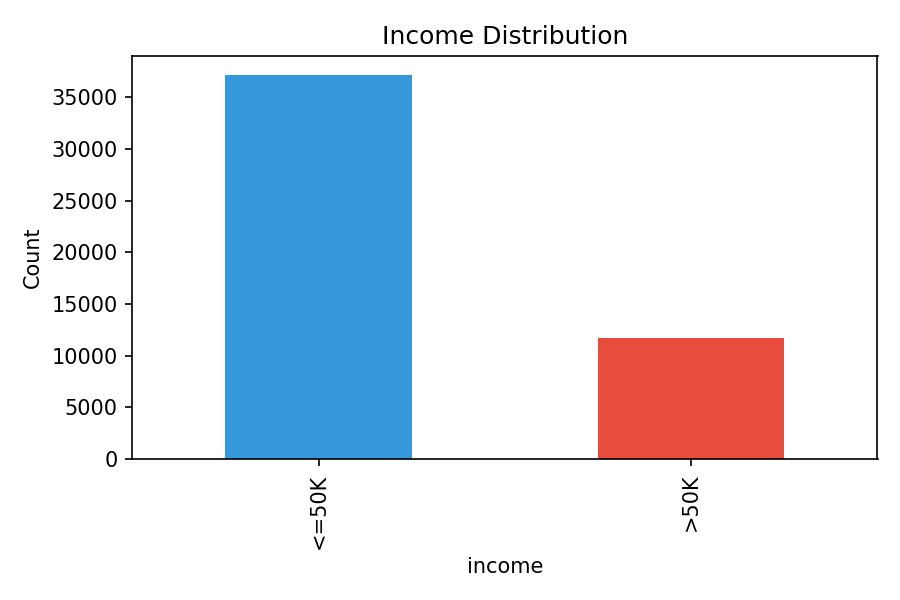

In [6]:
# Analyze target distribution & plot
analyze_usecase = container.analyze_target_usecase()
output_dir = os.path.join(os.getcwd(), "outputs/task1")
analyze_usecase.execute(output_dir)

# Render the saved target distribution plot
display(Image(os.path.join(output_dir, "target_distribution.png")))
